# tumor segmentation

## loading data

We'll look at a sample of our data. It contains four different MRI modalities (240x240x4) and the ground truth for tumor segmentation (240x240x3).

We load a slice using the function _load_and_normalize_slice_

The function normalizes the slices using z-score normalization with parameters calculated using the whole volume. Another output from our function is a binary brain mask which marks at least one of the modalities is different from zero.

To avoid edge artifact the function shaves off the edges of the brain mask using _scipy.ndimage.binary_erosion_

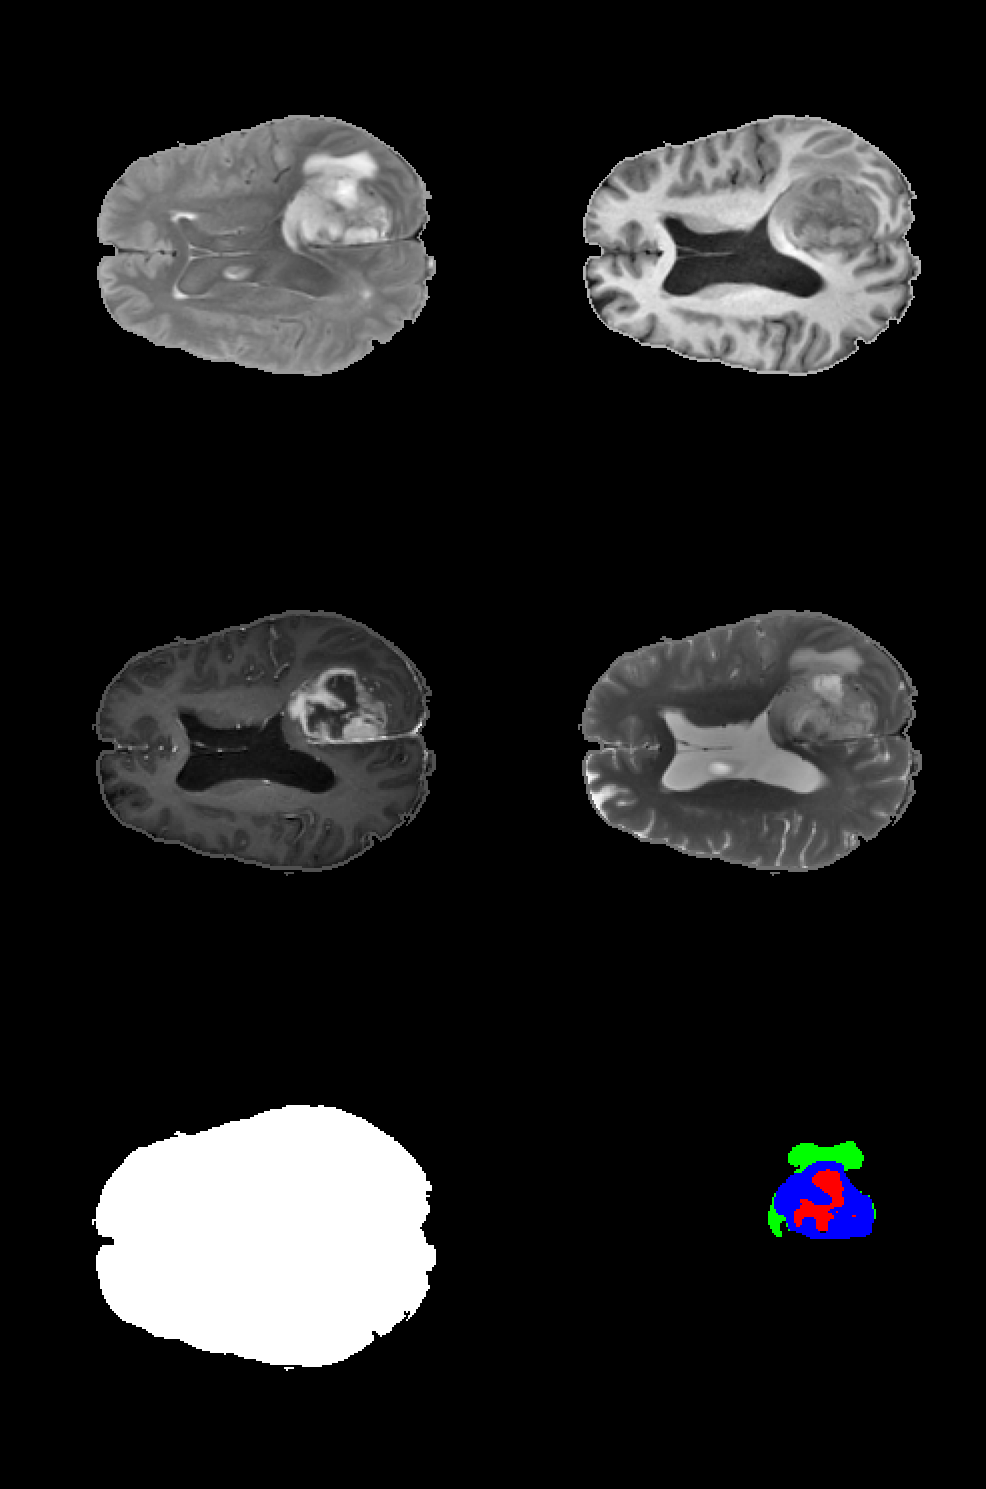

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from utilities.utils import load_and_normalize_slice

%matplotlib inline

norm_slice, brain_mask, gt_mask = load_and_normalize_slice(
    vol_num=350, slice_num=80
)

# Convert to float array to allow NaNs for background masking
masked_slice = norm_slice.astype(np.float64).copy()
masked_slice[~brain_mask, :] = np.nan

# Configure colormap to render NaNs as black
gray_cmap = mpl.colormaps["gray"].copy()
gray_cmap.set_bad(color="black")

fig, ax = plt.subplots(3, 2, figsize=(10, 15))

# Row 0 & 1: 4 Modalities with NaN background
ax[0, 0].imshow(masked_slice[:, :, 0], cmap=gray_cmap)
ax[0, 1].imshow(masked_slice[:, :, 1], cmap=gray_cmap)
ax[1, 0].imshow(masked_slice[:, :, 2], cmap=gray_cmap)
ax[1, 1].imshow(masked_slice[:, :, 3], cmap=gray_cmap)

# Row 2: Masks
ax[2, 0].imshow(brain_mask, cmap="gray")
ax[2, 1].imshow(gt_mask)

# Clean up axes ticks
for a in ax.flat:
    a.axis("off")

plt.tight_layout()
plt.show()

To get outputs appropriate for the symmetric model we use the "symmetric" flag. in this setup the image output has 8 channel - the four regular modalities and the NDI.

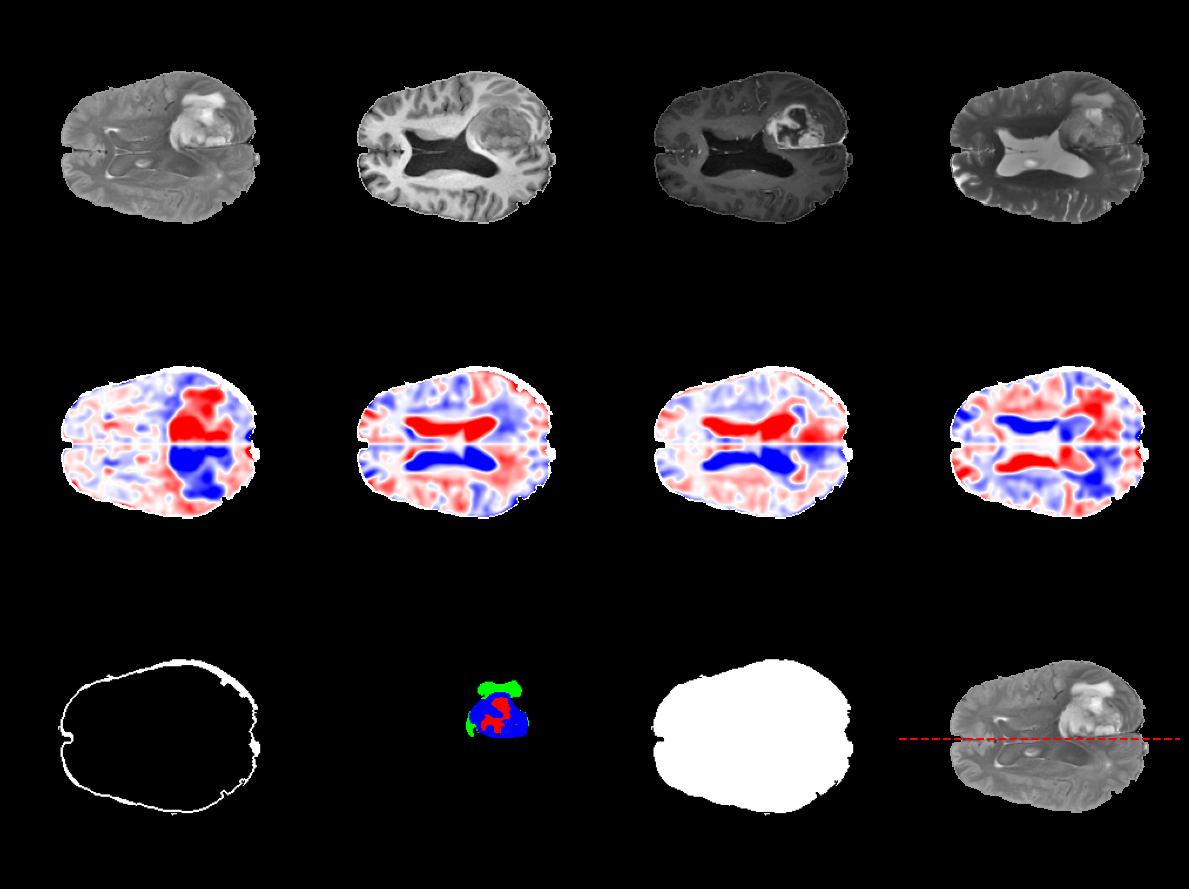

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

norm_slice, brain_mask, gt_mask, symmetry_mask = load_and_normalize_slice(
    vol_num=350, slice_num=80, symmetric=True, blur_sigma=2
)

# Convert to float array to allow NaNs for background masking
masked_slice = norm_slice.astype(np.float64).copy()
masked_slice[~brain_mask, :] = np.nan

gray_cmap = mpl.colormaps["gray"].copy()
gray_cmap.set_bad(color="black")

ndi_cmap = mpl.colormaps["bwr"].copy()
ndi_cmap.set_bad(color="black")

fig, ax = plt.subplots(3, 4, figsize=(12, 9))

# Row 0: Normalized 4 Base Modalities
for c in range(4):
    ax[0, c].imshow(masked_slice[:, :, c], cmap=gray_cmap)

# Row 1: 4 NDI Symmetry Channels (Blue = negative, Red = positive)
for c in range(4):
    ax[1, c].imshow(masked_slice[:, :, c + 4], cmap=ndi_cmap, vmin=-2, vmax=2)

# Row 2: Ground Truth, Brain Mask, Symmetry Mask, and Overlay Line
ax[2, 0].imshow(~symmetry_mask & brain_mask, cmap='gray')




ax[2, 1].imshow(gt_mask)
ax[2, 2].imshow(brain_mask, cmap='gray')

# Subplot 2,3: Brain Mask with Horizontal Symmetry Line
H = norm_slice.shape[0]
ax[2, 3].imshow(masked_slice[:,:,0], cmap='gray')
ax[2, 3].axhline(y=H // 2, color='red', linestyle='--', linewidth=1.5)

# Clean up axes ticks across all subplots
for a in ax.flat:
    a.axis('off')

plt.tight_layout()
plt.show()

## training

We'll train our models by accumulating pixels for each class and performing a gaussian micture fit. The parameters for the training are defined in the *config* file.

In [14]:
import os
from pathlib import Path
from config import *
from statistical_models.train_healthy import fit_and_save_healthy_gmm

print(f"Number of Gaussian components in healthy: {GMM_REGULAR_COMPONENTS}")
print(f"Number of Gaussian components in healthy (symmetric): {GMM_SYMMETRIC_COMPONENTS}")

# Define model paths relative to PROJECT_ROOT
models_dir = Path(PROJECT_ROOT) / 'saved_parameters' / 'statistical_models'
regular_gmm_path = models_dir / 'healthy_gmm.npz'
symmetric_gmm_path = models_dir / 'healthy_gmm_symmetric.npz'

# Check and train missing models
if not regular_gmm_path.exists():
    print(f"\n{regular_gmm_path.name} not found. Training regular GMM...")
    fit_and_save_healthy_gmm(symmetric=False)

if not symmetric_gmm_path.exists():
    print(f"\n{symmetric_gmm_path.name} not found. Training symmetric GMM...")
    fit_and_save_healthy_gmm(symmetric=True)

if regular_gmm_path.exists() and symmetric_gmm_path.exists():
    print("\nAll model parameters exist!")

Number of Gaussian components in healthy: 12
Number of Gaussian components in healthy (symmetric): 24

All model parameters exist!


In [15]:
import os
from pathlib import Path
from config import *
from statistical_models.train_tumor import fit_and_save_tumor_gaussian

# Define model paths relative to PROJECT_ROOT
models_dir = Path(PROJECT_ROOT) / 'saved_parameters' / 'statistical_models'
regular_tumor_path = models_dir / 'tumor_gaussian.npz'
symmetric_tumor_path = models_dir / 'tumor_gaussian_symmetric.npz'

# Check and train missing models
if not regular_tumor_path.exists():
    print(f"\n{regular_tumor_path.name} not found. Fitting regular tumor Gaussian...")
    fit_and_save_tumor_gaussian(symmetric=False)

if not symmetric_tumor_path.exists():
    print(f"\n{symmetric_tumor_path.name} not found. Fitting symmetric tumor Gaussian...")
    fit_and_save_tumor_gaussian(symmetric=True)

if regular_tumor_path.exists() and symmetric_tumor_path.exists():
    print("\nAll tumor model parameters exist!")


All tumor model parameters exist!


Let's evaluate each of the gmm components separately on a slice:

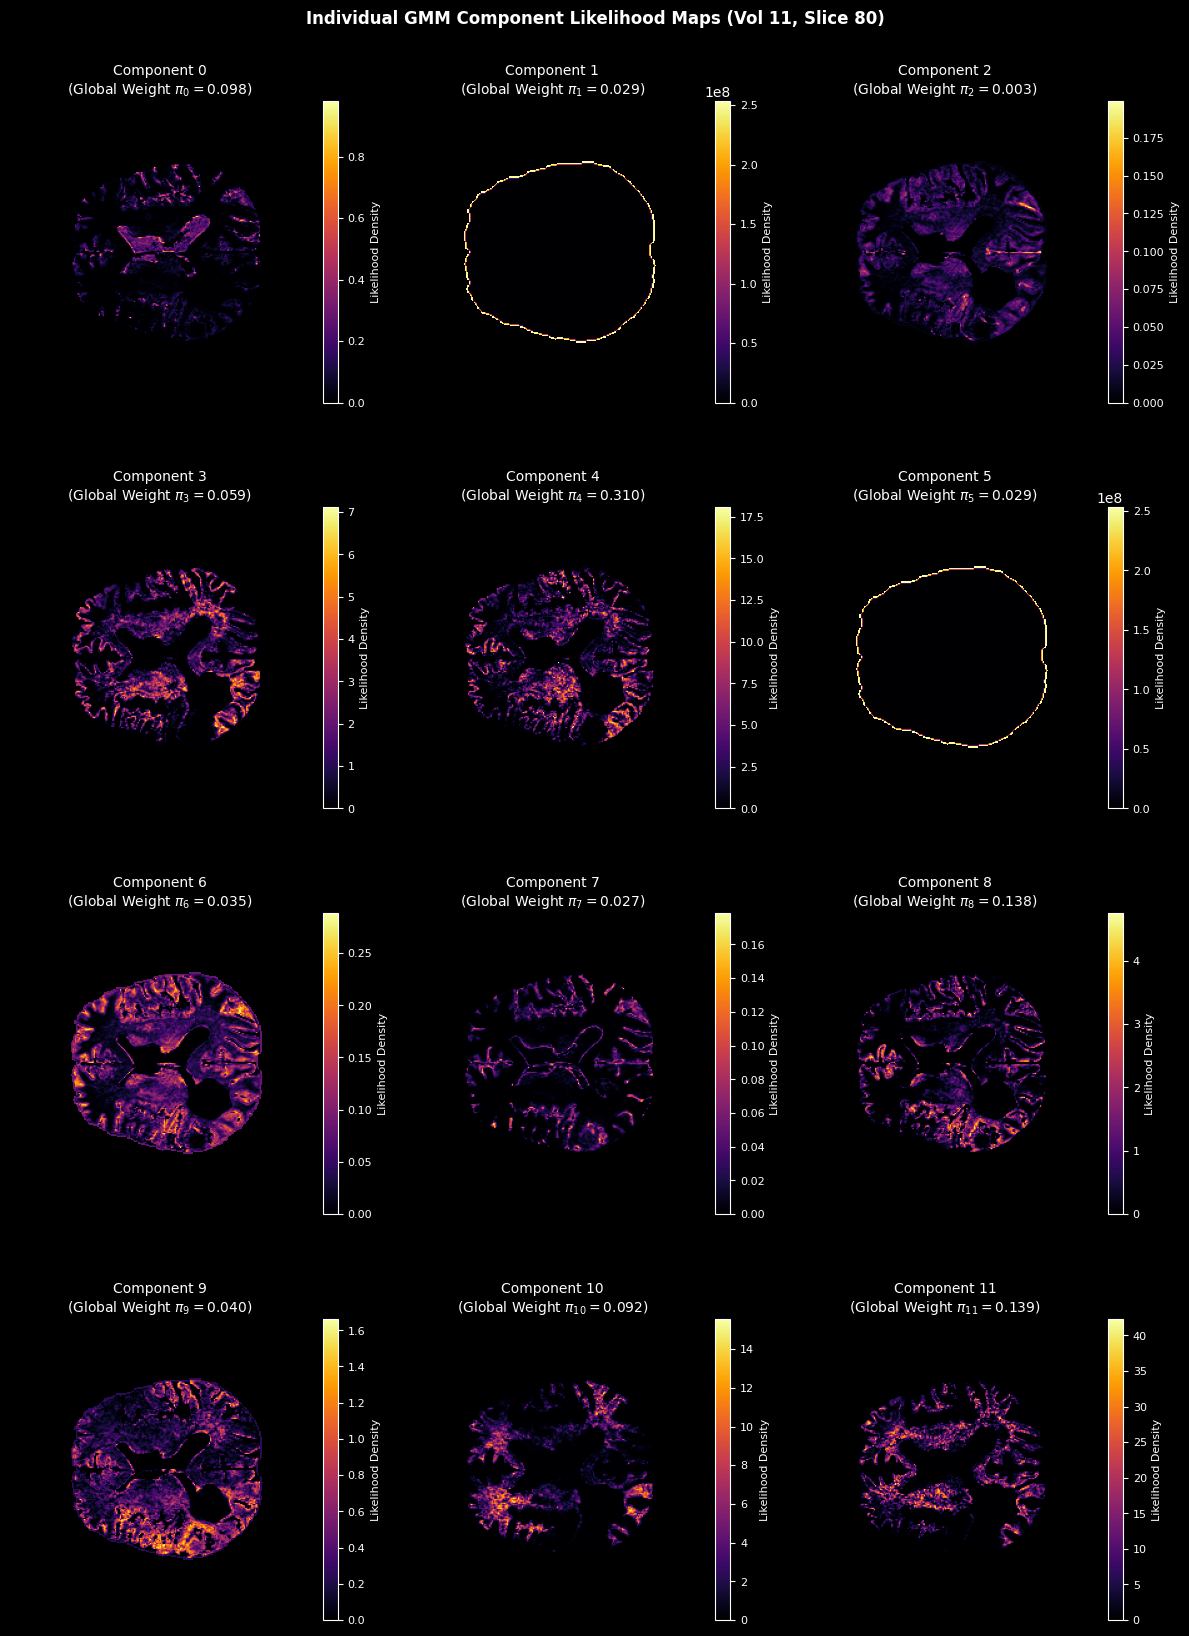

In [16]:
    from image_processing.gmm_component_visualization import plot_gmm_component_likelihoods
    from config import *
    %matplotlib inline



    likelihood_tensor = plot_gmm_component_likelihoods(vol_num=11, slice_num=SLICE_NUM, symmetric=False, cols=3 )

In [17]:
import os
from pathlib import Path
from config import *
from statistical_models.train_local_weights import compute_and_save_local_weights

# Define model paths relative to PROJECT_ROOT
models_dir = Path(PROJECT_ROOT) / 'saved_parameters' / 'statistical_models'
regular_weights_path = models_dir / 'local_weights.npz'
symmetric_weights_path = models_dir / 'local_weights_symmetric.npz'

# Check and train missing local weight maps
if not regular_weights_path.exists():
    print(f"\n{regular_weights_path.name} not found. Computing regular local weights...")
    compute_and_save_local_weights(symmetric=False)

if not symmetric_weights_path.exists():
    print(f"\n{symmetric_weights_path.name} not found. Computing symmetric local weights...")
    compute_and_save_local_weights(symmetric=True)

if regular_weights_path.exists() and symmetric_weights_path.exists():
    print("\nAll local weight map parameters exist!")


All local weight map parameters exist!


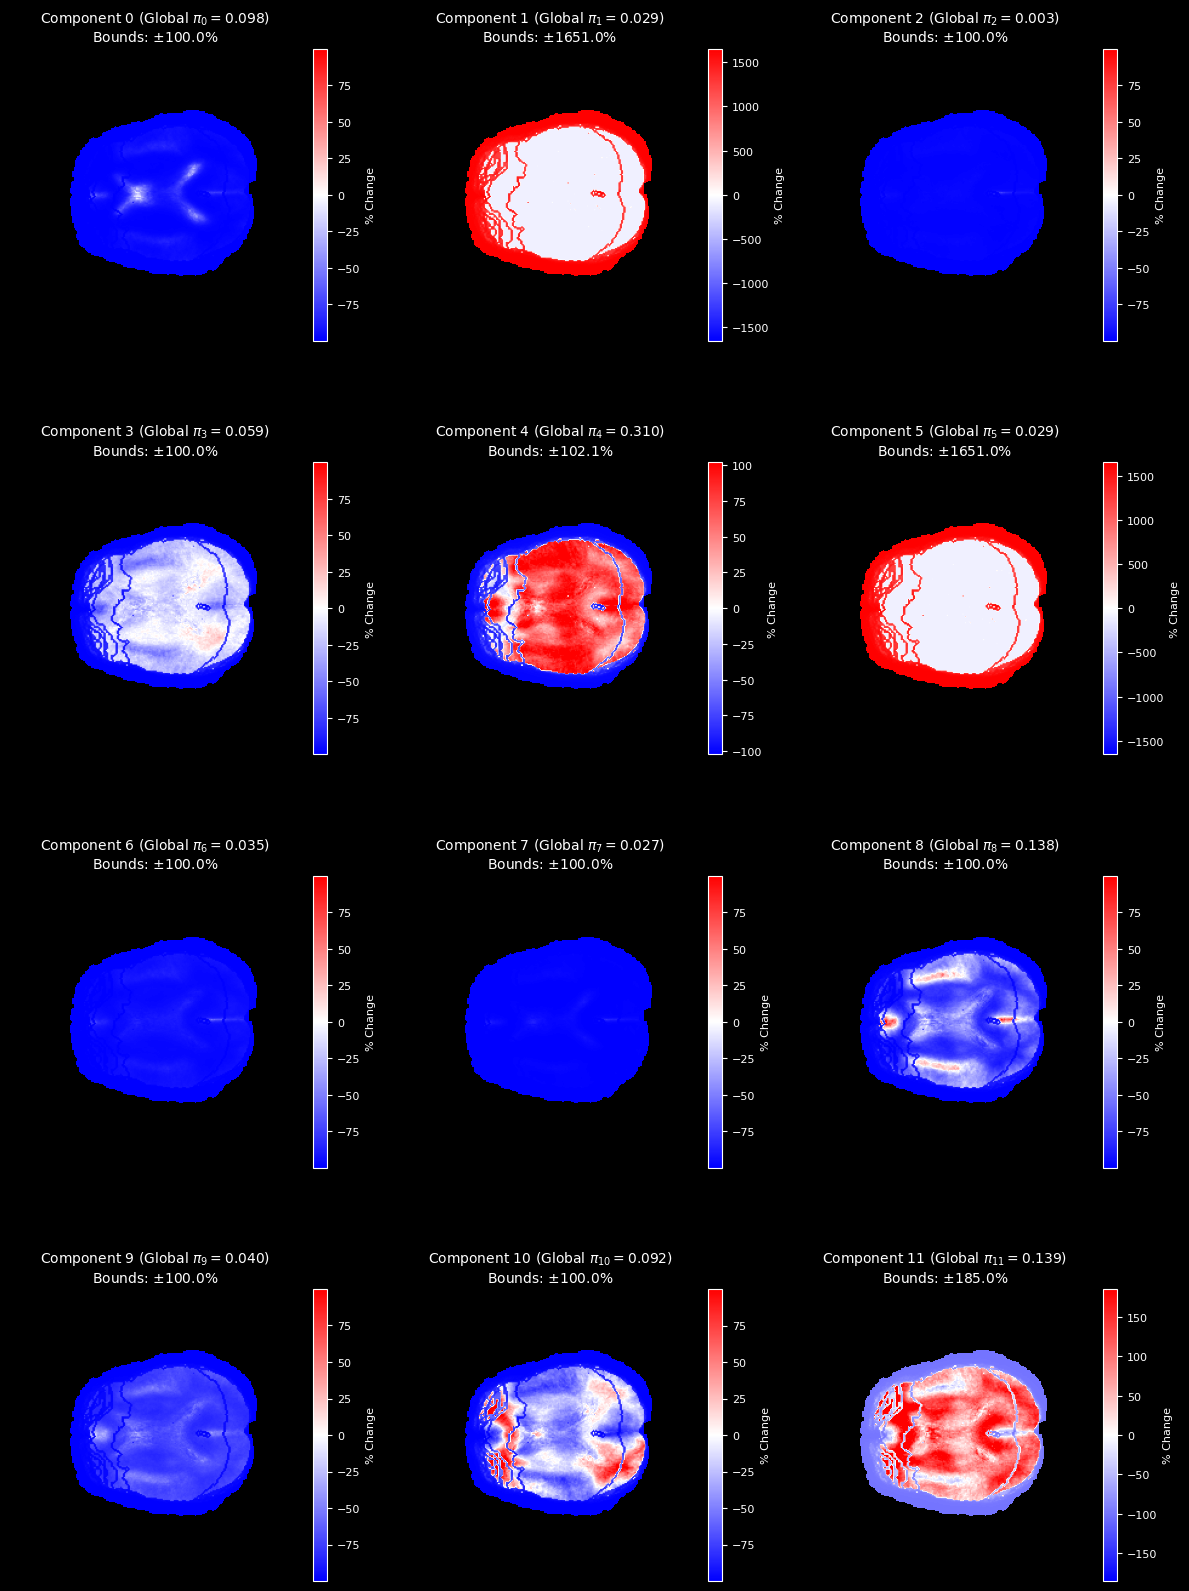

In [18]:

%matplotlib inline
from config import *
from image_processing.local_weights_visualization import plot_local_vs_global_weight_changes

plot_local_vs_global_weight_changes(vol_num=13, slice_num=SLICE_NUM, cols=3)

Our algorithm follows these steps:

- alculate the likelihood times prior of each class

- Stack and normalize to get posterior maps for each class

- Detect edges using a Sobel filter

- Detect contours

- Classify blobs based on their entropy weighted posterior average

- Expand the blob to adjacent pixels if their probability meets a ambiguity threshold

All of this is wrapped in _eval_vol_

Dice: 0.768, IOU: 0.623



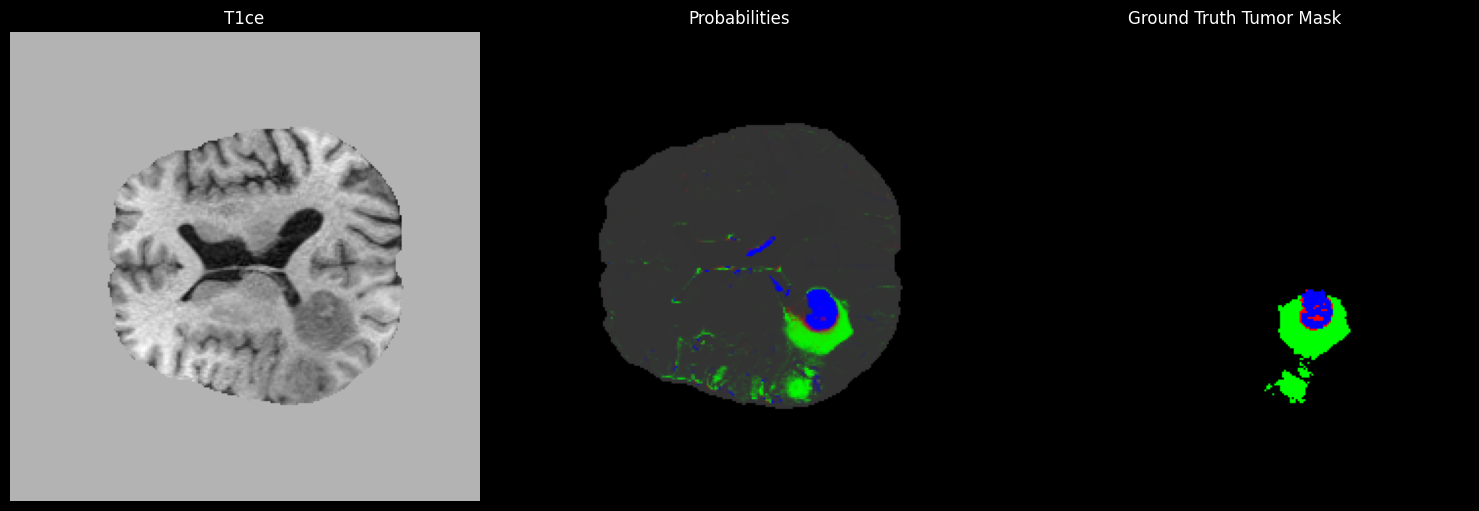

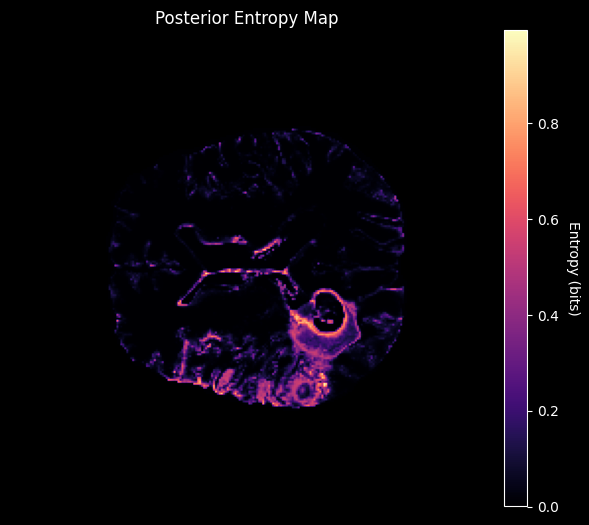

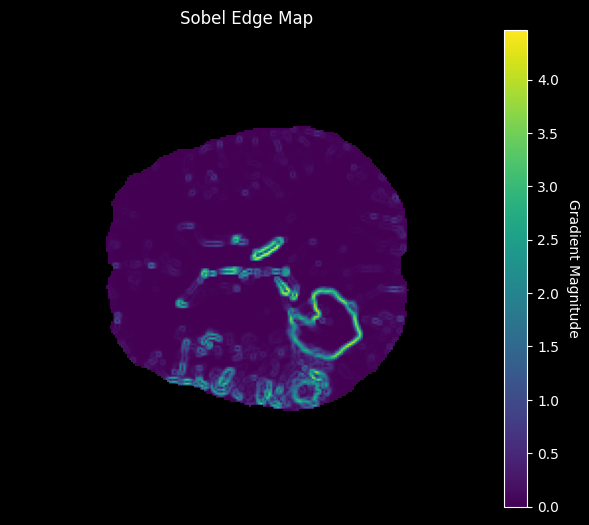

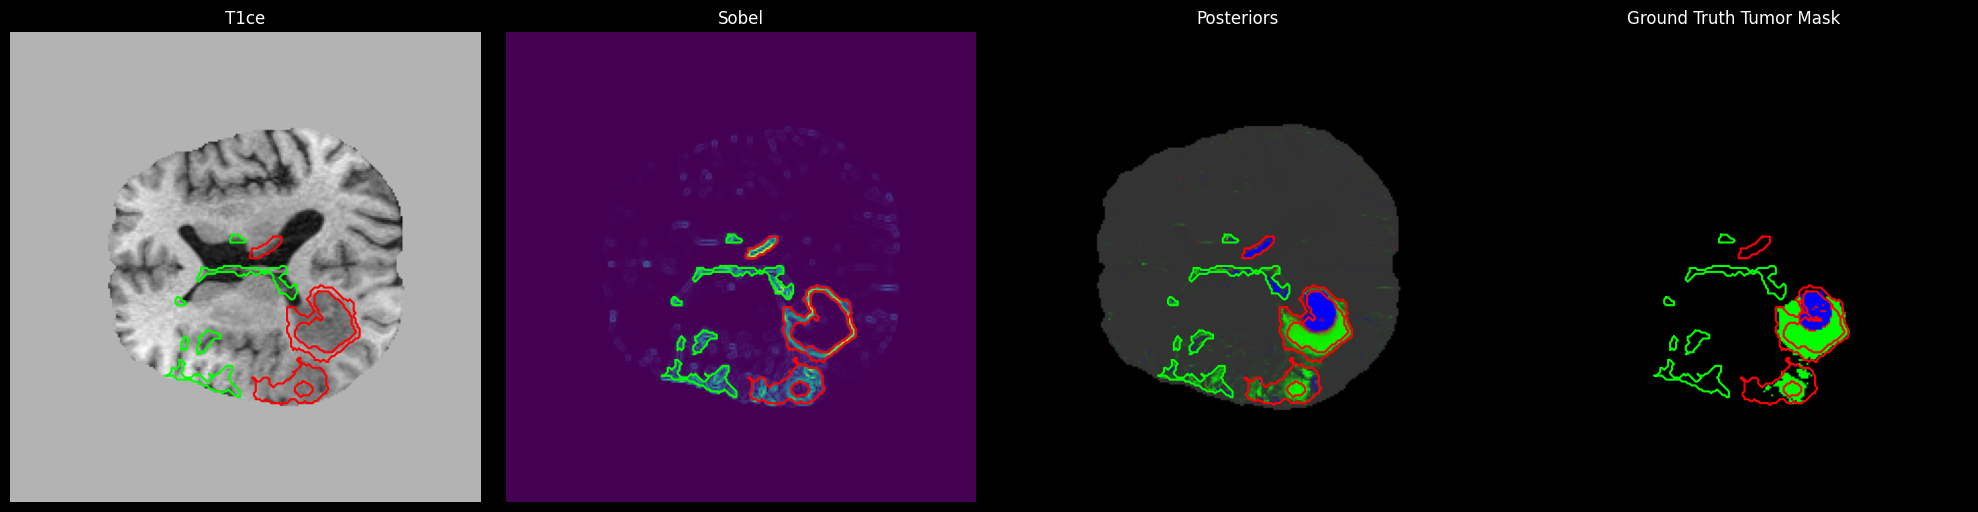

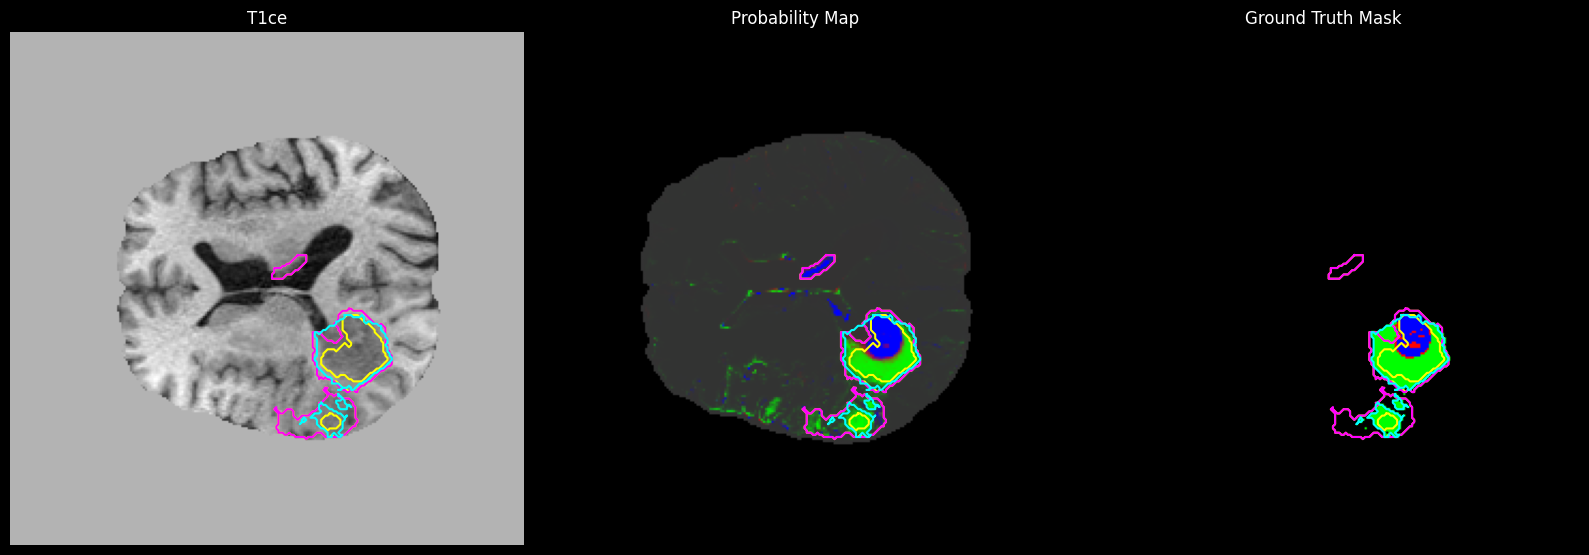

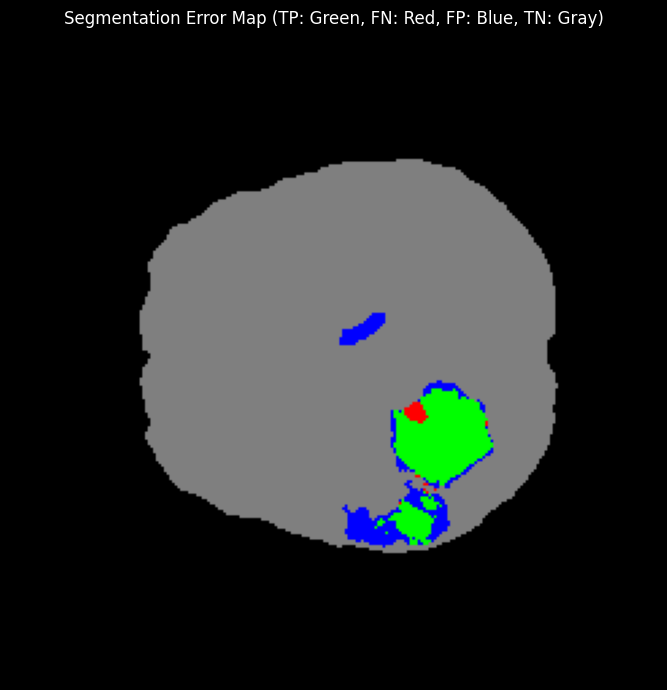

(np.float64(0.7675090252707578),
 np.float64(0.6227299355594607),
 np.int64(1063),
 np.int64(1707),
 np.int64(1650),
 np.int64(1120))

In [19]:
from evaluation.evaluate_single_slice import eval_vol
from config import *
%matplotlib inline

vol_num = 11


eval_vol(vol_num,
             target_row=None,
             diagnostic_figures = True,
             verbose = True,
             symmetric = True,

             lambda_val             = LAMBDA,

             min_pixels_per_blob    = MIN_NUM_PIXELS_PER_BLOB_DEFAULT,
             allow_internal       = ALLOW_INTERNAL_CONTOURS,
             binarization_factor   = SOBEL_BINARIZATION_OTSU_FACTOR,

             blob_class_threshold = WEIGHTED_POSTERIOR_MEAN_THRESHOLD,

             entropy_thresh       = ENTROPY_THRESHOLD_DEFAULT,
             posterior_min        = POSTERIOR_THRESHOLD_DEFAULT,
             max_expansion_diameter= MAX_EXPANSION_DIAMETER_DEFAULT
             )

To get the best results we use Optuna to optimize the hyper-parameters.

See _evaluation/hyperparemeter_ for greater detail.

Notice that results differ if we optimize for dice score over the whole dataset globally or optimize for the mean of dice scores of each volume.

Notice also that overfitting is a concern, especially for global optimization.

In [20]:
from evaluation.hyperprameter_optimization import run_optimization

# 1. Optimize for Mean Per-Volume Dice Score
# run_optimization(n_trials=50, symmetric=False, metric_mode="volumewise")

# 2. Optimize for Pooled Global Dataset Dice Score
# run_optimization(n_trials=50, symmetric=True, metric_mode="global")

We plug these values into the config file and run an evaluation on the test dataset

In [21]:
from evaluation.evaluate_test_set import eval_dataset

eval_dataset(model_name="example",symmetric=True)

Evaluating 69 test volumes (Mode: SYMMETRIC)...

  DATASET EVALUATION COMPLETE (EXAMPLE - SYMMETRIC)
Global Dataset Dice   : 0.7890
Global Dataset IoU    : 0.6515
--------------------------------------------------
Mean Volumewise Dice  : 0.6179
Mean Volumewise IoU   : 0.5420
--------------------------------------------------
Completely Missed     : 8 / 60 volumes with tumors


Histogram saved successfully to: /Users/danielr/PycharmProjects/MRI/output/diagnostic_figures/example_regular_metrics_lambda_0.45_dice_per_volume_hist.png


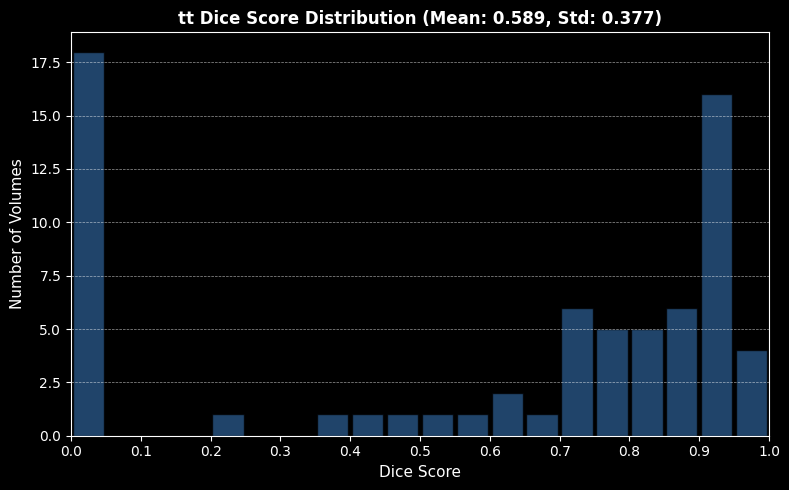

In [22]:
from evaluation.eval_visualizations import plot_metrics_histogram

plot_metrics_histogram(
    "tt",
    "output/evaluation_scores/example_regular_metrics_lambda_0.45.npz",
    metric_key="dice_per_volume")